**I302 - Aprendizaje Automático y Aprendizaje Profundo**

<h1 style="text-align: center;"><strong>Trabajo Práctico 3: Redes Neuronales</strong></h1>

*Agustín A. Pereyra*

---

El presente trabajo tiene el objetivo de implementar y estudiar diferentes modelo de redes neuronales para clasificación multiclase a partir de un dataset de caracteres japoneses. Se implementan modelos básicos como modelos más avanzados con ciertas mejoras como optimización Adam, SGD, Regularización, etc. Al final se comparan estos modelos implementados *form scratch* con modelos definidos utilizando la librería de Machine Learning: PyTorch.

## 1. Análisis y Preprocesamiento de Datos

In [95]:
%load_ext autoreload
%autoreload 2
import numpy as np
np.random.seed(36631)
from pprint import pprint
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Yu Gothic' # fuente que contiene caracteres japoneses para mostrar labels verdaderos

from src.models import NN
from src.optimizers import GD, Momentum, AdaGrad, Adam, AdamW
from src.torch_models import TorchNN
from src.plots import show_images, show_class_samples, labels_distribution, training_summary, \
    batch_test_plot, optimizer_test_plot, lr_scheduling_test_plot, weight_decay_test_plot
from src.model_selection import batch_test, optimizer_test, lr_scheduling_test, weight_decay_test,\
    grid_search

import torch

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
X = np.load('data/X_images.npy')
y = np.load('data/y_images.npy')

El dataset de este trabajo parece corresponder a un subconjunto de [**Kuzushiji-MNIST**, **K49**](https://github.com/rois-codh/kmnist) o alguno similar en el que se tienen imágenes de 28x28 píxeles de escritos de caracteres japoneses. Entre ellas encontramos 49 clases diferentes a identificar con nuestros modelos. 

> [**Disclaimer**] Los labels (en japonés) asignados en este trabajo fuerom tomados del [dataset original](https://arxiv.org/abs/1812.01718), por lo que es posible que haya
> alguna confusión con alguno.

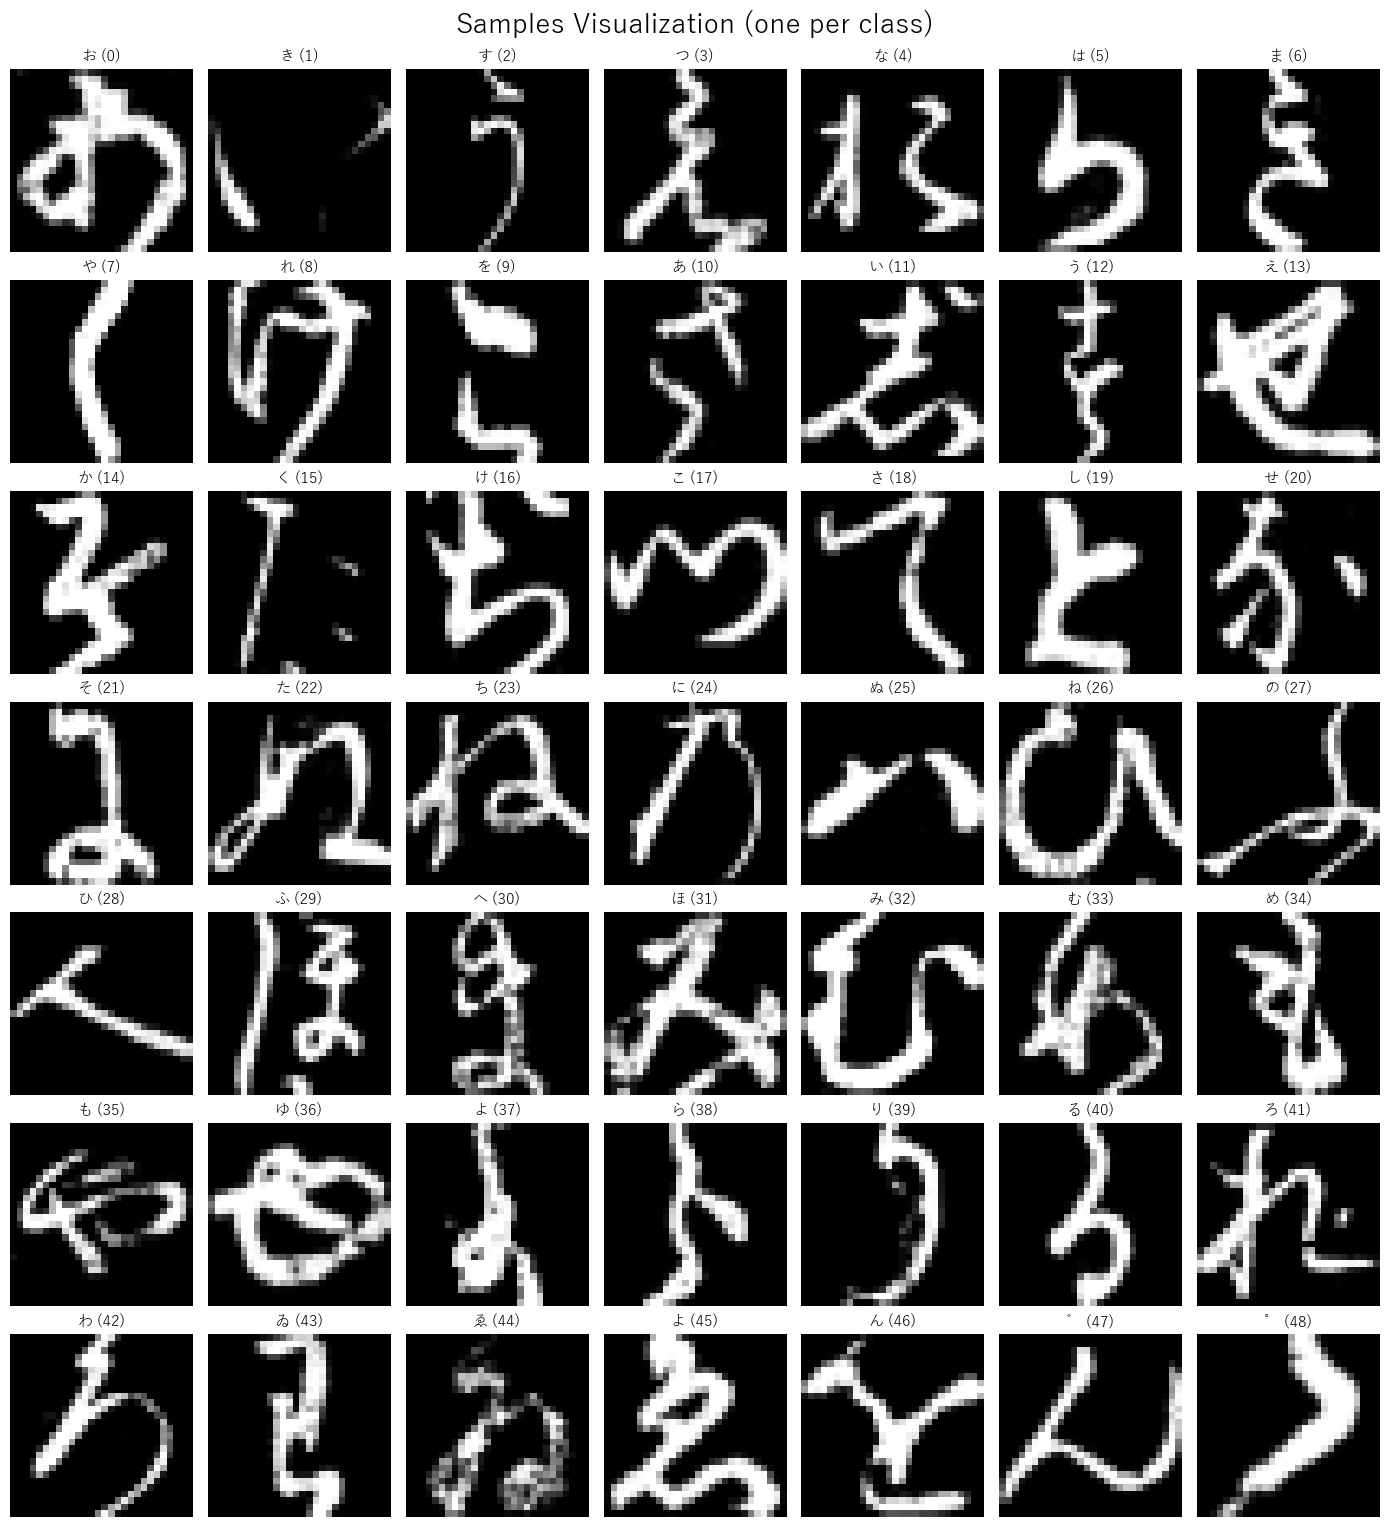

In [3]:
show_images(X, y)

Al observar varias muestras de una misma clase veremos que en general los trazos para cada caracter difieren significativamente, como suele pasar en estos tipos de dataset de la familia MNIST.

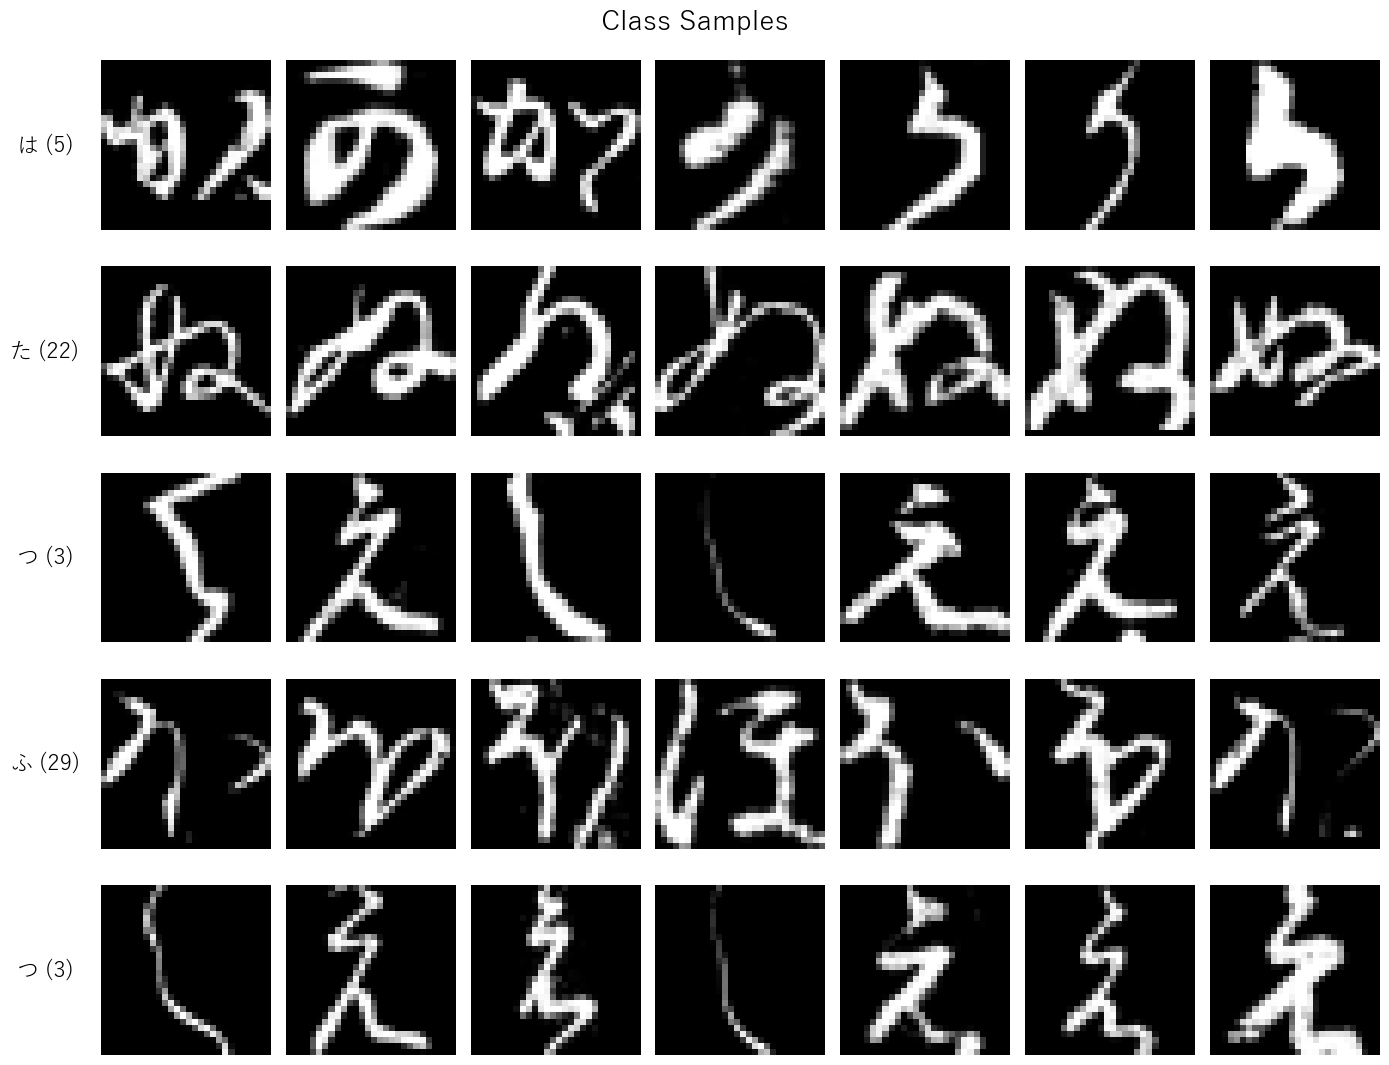

In [4]:
show_class_samples(X, y, labels=np.random.randint(low=0, high=49, size=5).tolist(), n=7)

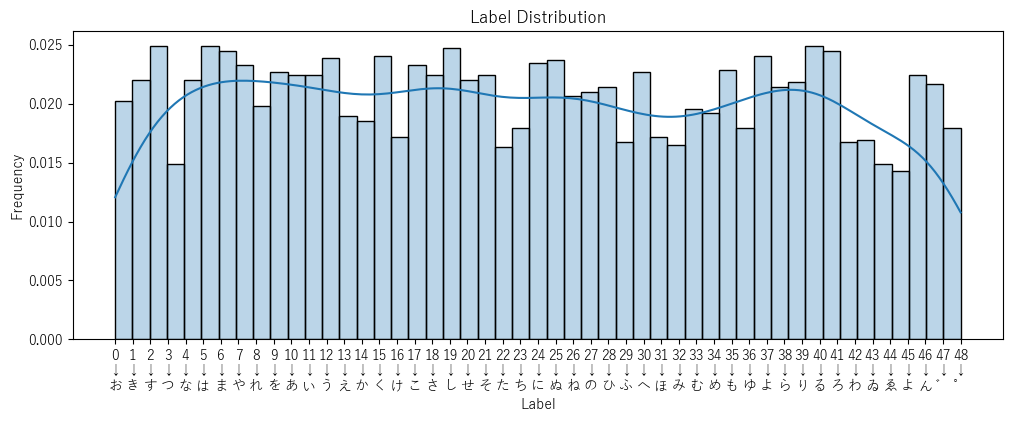

In [5]:
labels_distribution(y)

### **Normalización**

Los pixeles de las imágenes se dividirán por 255 de manera que todos los valores quede acotados en $[0,1]$

In [6]:
X = X / 255

### **División** del Dataset

In [7]:
idx = np.random.permutation(len(X))

test_size = int(0.2 * len(X)) # 20% test
dev_idx, test_idx = idx[test_size:], idx[:test_size]

X_dev, y_dev = X[dev_idx],  y[dev_idx]
X_test, y_test = X[test_idx], y[test_idx]

val_size = int(0.2 * len(X_dev)) # 20% del dev para val
dev_idx = np.random.permutation(len(X_dev))
train_idx, val_idx = dev_idx[val_size:], dev_idx[:val_size]

X_train, y_train = X_dev[train_idx],  y_dev[train_idx]
X_val, y_val = X_dev[val_idx], y_dev[val_idx]

In [8]:
input_size = X[0].size
output_size = np.unique(y).size

## 2. Implementación y Entrenamiento de una Red Neuronal Básica

### **Modelo** $\boldsymbol{M_0}$

El primer modelo implementado de un Multi-Layer Perceptron (MLP) básico que utiliza Gradient Descent Estándar y 2 capas ocultas con función de activación ReLU y una capa final de salida Softmax.

$$
\text{ReLU}(x) = \max(0,x)
$$

A continuación se detallan particularidades del modelo, como la función de costo y el resultado de la combinación de esta función de costo y la capa de salida Softmax sobre el algoritmo de **back-propagation**.

### **Función de Costo**: *Cross-Entropy*

Para un problema de clasificación multiclase con $K$ clases, la función de costo utilizada es la **cross-entropy**, que mide la disimilitud entre la distribución predicha $\mathbf{z}^{(L)}=\hat{\mathbf{y}}$ y la distribución verdadera $\mathbf{y}$ (one-hot):

$$
\mathcal{L}(\mathbf{y}, \hat{\mathbf{y}}) = -\sum_{k=1}^{K} y_k \log \hat{y}_k
$$

Como $\mathbf{y}$ es one-hot (solo una clase es 1, el resto son 0), la sumatoria colapsa a un único término:

$$
\mathcal{L} = -\log \hat{y}_{c}^{}
$$

donde $c$ es la clase verdadera. Para un batch de $m$ ejemplos, promediamos:

$$
\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_k^{(i)} \log \hat{y}_k^{(i)}
$$

La función de costo es mínima cuando el modelo asigna probabilidad 1 a la clase correcta, y crece hacia infinito cuando le asigna probabilidad 0.

### **Backpropagation en la Capa de Salida**: *Softmax + Cross-Entropy*

Para una red neuronal de $L$ capas con **Softmax** como función de activación de la capa de salida y **entropía cruzada** como función de pérdida, el error de propagación en esta última capa $\boldsymbol{\delta}^{(L)} = \frac{\partial \mathcal{L}}{\partial \mathbf{a}^{(L)}}$, es decir el gradiente de la pérdida respecto a la pre-activación de la última capa, se obtiene aplicando la regla de la cadena:

$$
\boldsymbol{\delta}_k^{(L)} = \frac{\partial \mathcal{L}}{\partial \mathbf{a}_k^{(L)}} = \sum_{j} \frac{\partial \mathcal{L}}{\partial \mathbf{z}_j^{(L)}} \cdot \frac{\partial \mathbf{z}_j^{(L)}}{\partial \mathbf{a}_k^{(L)}}
$$

**Gradiente de la cross-entropy respecto a la activación de salida:**

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{z}_j^{(L)}} = -\frac{y_j}{\mathbf{z}_j^{(L)}}
$$

**Jacobiano de la Softmax** (función vectorial $\mathbb{R}^K \to \mathbb{R}^K$, no escalar):

$$
\frac{\partial \mathbf{z}_j^{(L)}}{\partial \mathbf{a}_k^{(L)}} = \mathbf{z}_j^{(L)}\left(\mathbb{I}[j = k] - \mathbf{z}_k^{(L)}\right)
$$

donde $\mathbb{I}[j = k]$ es la función indicadora. Sustituyendo ambas expresiones:

$$
\boldsymbol{\delta}_k^{(L)} = \sum_{j} \left(-\frac{y_j}{\mathbf{z}_j^{(L)}}\right) \mathbf{z}_j^{(L)}\left(\mathbb{I}[j = k] - \mathbf{z}_k^{(L)}\right) = -\sum_{j} y_j \left(\mathbb{I}[j = k] - \mathbf{z}_k^{(L)}\right)
$$

Expandiendo y usando que $\sum_j y_j = 1$ (one-hot):

$$
\boldsymbol{\delta}_k^{(L)} = -y_k + \mathbf{z}_k^{(L)} \underbrace{\sum_{j} y_j}_{=1} = \mathbf{z}_k^{(L)} - y_k
$$

En forma vectorial, el resultado es notablemente simple:

$$
\boldsymbol{\delta}^{(L)} = \mathbf{z}^{(L)} - \mathbf{y} = \hat{\mathbf{y}} - \mathbf{y}
$$

Esta simplificación es la razón principal por la que la combinación softmax + cross-entropy es estándar en clasificación multiclase: el Jacobiano completo de la softmax (una matriz $K \times K$) se cancela algebraicamente y el gradiente resultante es solo la diferencia entre la predicción y el target. Esto es numéricamente estable y computacionalmente eficiente.

### **Inicialización de Parámetros**: *He initialization*

Para una red neuronal es fundamental el rol de la inicialización de pesos, puesto que en caso de no considerarla podríamos llevar a que esta no se entrena en lo absoluto a pesar de ejecutar el algoritmo entero de entrenamiento por el **problema de simetría**. Lo esencial es que los pesos se inicialicen de forma aleatoria y con valores no lejanos al 0 para no provocar una explosión de gradiente dentro de **backpropagation**. 

En esta ocasión utilizaremos la inicialización llamada **He initialization**, una variante de la típica **Glorot/Xavier initialization** en la que la distribución normal utilizada para samplear cada parámetro $(w_{ij}^{(\ell)}\sim \mathcal{N}(0,\sigma^2))$ se define a partir de la cantidad del *fan in* (número de conexiones entrantes)

$$
\sigma^2 = \frac{2}{n_\text{in}}
$$

Como indican las bibliografías de la materia, el método de inicialización **depende de las funciones de activación** de la red, por esto se seleccionó esta inicialización que es la recomendada para utilizar en redes con activaciones ReLU y sus variantes.

In [9]:
M0_layers = [(128, 'relu'), (64, 'relu')]
M0 = NN(input_size, output_size, layers=M0_layers, optimizer=GD)
M0_train_hist = M0.fit(X_train, y_train, X_val, y_val, epochs=400)

Training: 100%|██████████| 400/400 [00:29<00:00, 13.43epoch/s, train_loss=0.7893, val_loss=1.7256]


Training [completed] — epoch: 400 | train_loss: 0.7893 | val_loss: 1.7256 | time: 29.8s


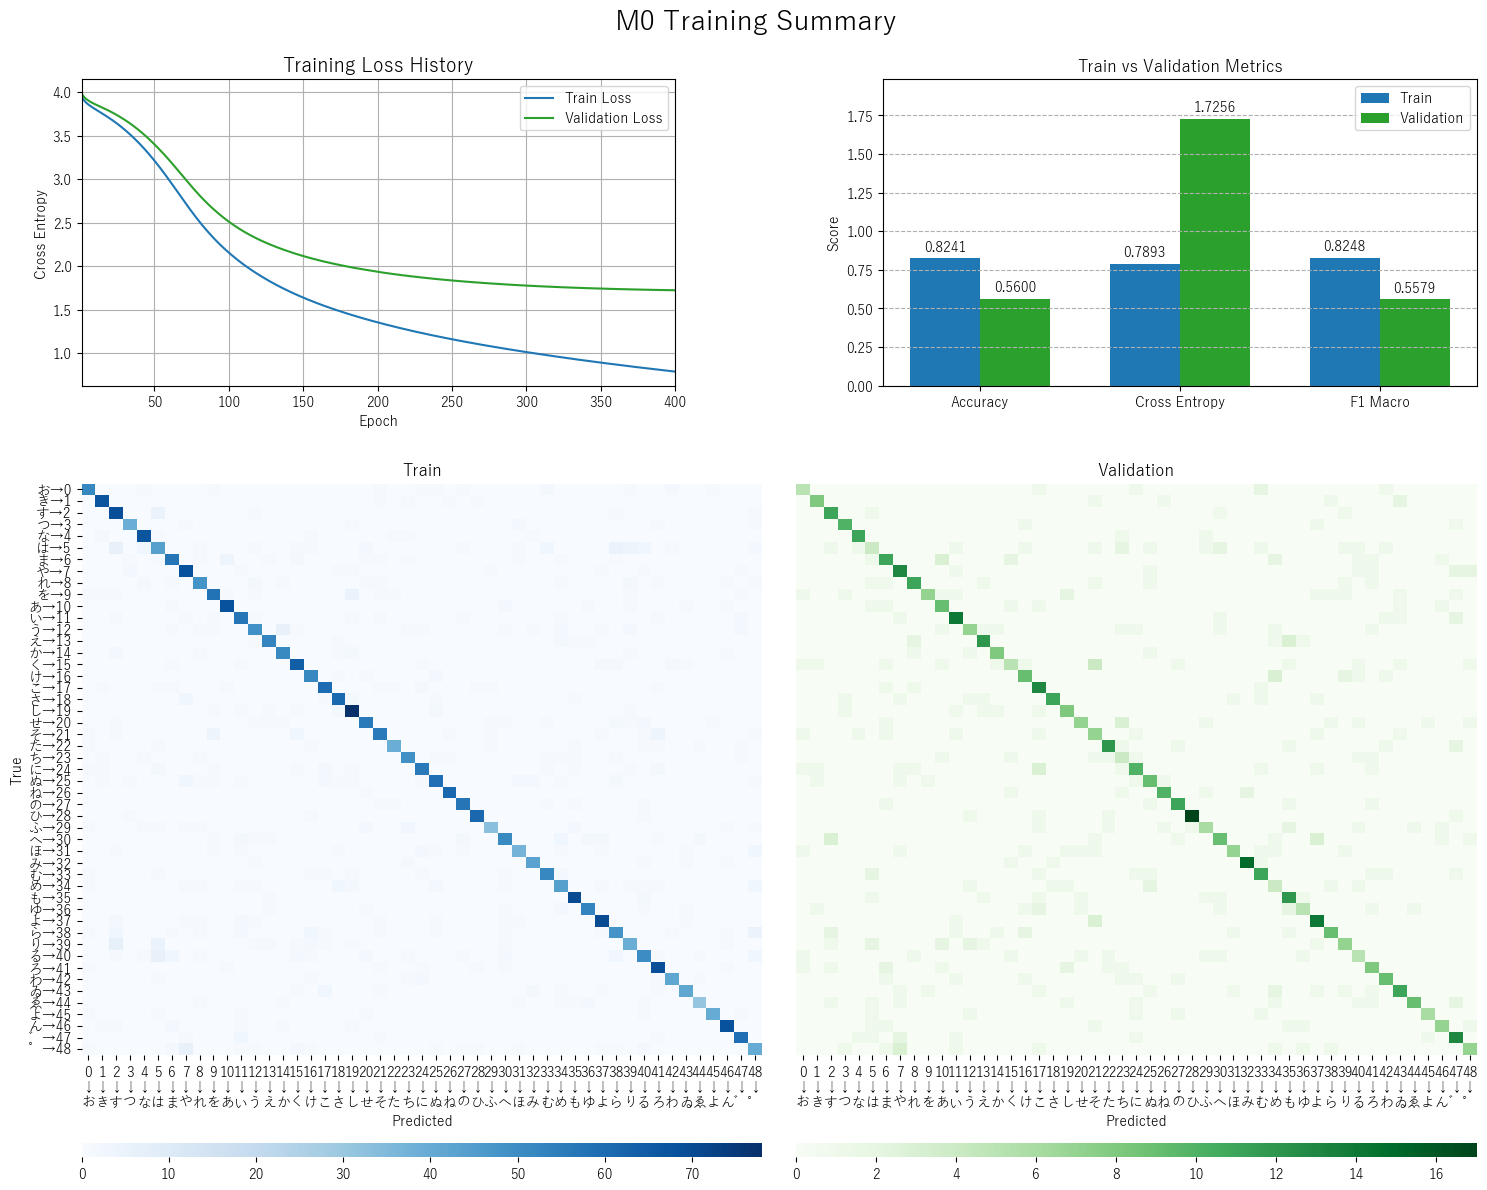

In [10]:
training_summary(M0, M0_train_hist, X_train, y_train, X_val, y_val, title='M0 Training Summary')

## 3. Implementación y Entrenamiento de una Red Neuronal Avanzada

En esta sección se realizan ciertas mejoras al modelo de la Red Neuronal. Se utilizan las siguientes mejoras y opciones de regularización en el entrenamiento del modelo. 

Se analizará el efecto marginal de cada uno de estas mejoras sobre los modelos resultantes respecto al modelo básico $M_0$:

### **Entrenamiento**: *Mini-batch SGD*

El gradiente descendente estándar (*batch GD*) computa el gradiente de la función de costo sobre **todo** el conjunto de entrenamiento en cada iteración:

$$
\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta \nabla_{\boldsymbol{\theta}} \mathcal{L}(\boldsymbol{\theta}_t)
$$

Si bien este gradiente es exacto, resulta prohibitivamente costoso para datasets grandes. El **Descenso de Gradiente Estocástico** (SGD) usa un único ejemplo por iteración, lo que introduce mucha varianza. El balance entre ambos extremos es el **mini-batch SGD**: en cada iteración se selecciona aleatoriamente un subconjunto $\mathcal{B}_t \subset \{1, \ldots, N\}$ de tamaño $|\mathcal{B}| = B$ y se computa el gradiente solo sobre esos ejemplos:

$$
\nabla_{\boldsymbol{\theta}} \mathcal{L} \approx \frac{1}{B} \sum_{i \in \mathcal{B}_t} \nabla_{\boldsymbol{\theta}} \ell(\boldsymbol{\theta};\, \mathbf{x}^{(i)}, \mathbf{y}^{(i)})
$$

Este estimador del gradiente es **insesgado**, ya que $\mathbb{E}_{\mathcal{B}}[\hat{g}] = \nabla \mathcal{L}$, y su varianza decrece con $B$. El ruido introducido por el mini-batch actúa como un regularizador implícito que puede ayudar a escapar de mínimos locales pobres.

En la práctica, al comienzo de cada época se **permuta aleatoriamente** el dataset y luego se recorre en bloques de tamaño $B$, de modo que todos los ejemplos sean vistos exactamente una vez por época. Una **época** queda definida como un recorrido completo sobre el conjunto de entrenamiento, independientemente del tamaño del batch. La regla de actualización en el paso $t$ es:

$$
\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta \cdot \frac{1}{B} \sum_{i \in \mathcal{B}_t} \nabla_{\boldsymbol{\theta}} \ell_i(\boldsymbol{\theta}_t)
$$

In [87]:
batch_results = batch_test(
    M0, X_train, y_train, X_val, y_val, 
    batch_sizes=[1, 64, 128, 512, 1024, 2048, None], 
    fit_params=dict(epochs=300)
    )

batch_size=None: 100%|██████████████████| 7/7 [09:43<00:00, 83.35s/batch, val_loss=1.7963]


En esta prueba vemos la evolución de la función de costo tanto en el conjunto de entrenamiento como en el de validación a lo largo de 300 épocas de entrenamiento para el modelo $M_0$ con diferentes batch_sizes de SGD.

En el caso de SGD puro (*batch_size=1*) el error de en el conjunto de validación

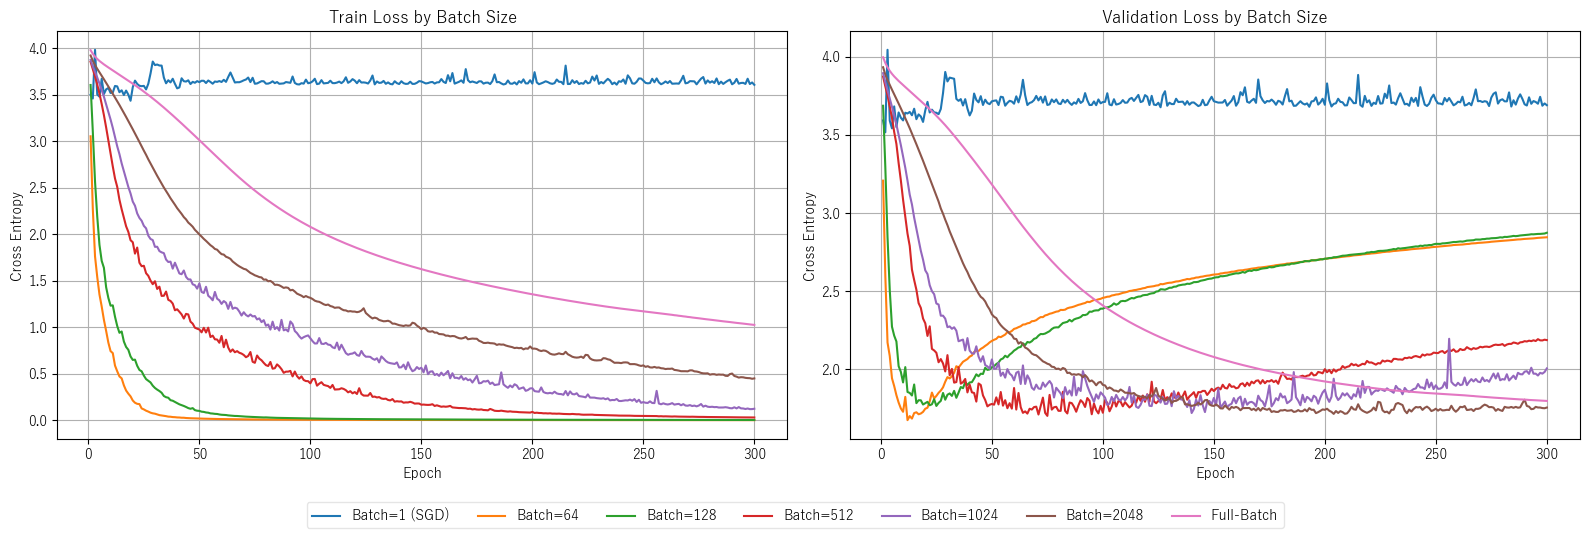

In [88]:
batch_test_plot(batch_results)

### **Optimizador**: *Adam*

El gradiente descendente estándar aplica la misma tasa de aprendizaje $\eta$ a todos los parámetros. [**Adam**](https://arxiv.org/abs/1412.6980) (*Adaptive Moment Estimation*, Kingma & Ba, 2014) mantiene estimaciones adaptativas de los dos primeros momentos del gradiente para cada parámetro, logrando pasos efectivos distintos por dimensión.

Define $\mathbf{g}_t = \nabla_{\boldsymbol{\theta}} \mathcal{L}_t$ el gradiente en el paso $t$. Adam mantiene:

- $\mathbf{m}_t$: estimación del **primer momento** (media del gradiente)
- $\mathbf{v}_t$: estimación del **segundo momento** "crudo" (varianza no centrada del gradiente)

Calculándolos tal que:

$$
\mathbf{m}_t = \beta_1\, \mathbf{m}_{t-1} + (1 - \beta_1)\, \mathbf{g}_t
$$

$$
\mathbf{v}_t = \beta_2\, \mathbf{v}_{t-1} + (1 - \beta_2)\, \mathbf{g}_t \odot \mathbf{g}_t
$$

donde $\beta_1, \beta_2 \in [0,1)$ son hiperparámetros que controlan el ratio de decaimiento exponencial de los momentos.

Como $\mathbf{m}_0 = \mathbf{v}_0 = \mathbf{0}$, ambas estimaciones están sesgadas hacia cero al comienzo del entrenamiento. Se corrige dividiendo por el factor de sesgo correspondiente:

$$
\hat{\mathbf{m}}_t = \frac{\mathbf{m}_t}{1 - \beta_1^t}, \qquad \hat{\mathbf{v}}_t = \frac{\mathbf{v}_t}{1 - \beta_2^t}
$$

La regla de actualización de los parámetros es entonces:

$$
\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta\, \frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon}
$$

donde $\epsilon > 0$ es un término de estabilidad numérica que evita divisiones por cero. Los hiperparámetros recomendados por los autores del algoritmo son $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$.

In [ ]:
optimizers = [GD, Momentum, AdaGrad, Adam]
optimizers_parameters = [{'lr':0.1}, {'lr':0.1}, {'lr':1e-2}, {'lr':[1e-2,5e-3]}]
optimizer_results = optimizer_test(M0, X_train, y_train, X_val, y_val, 
                                   optimizers=optimizers, parameters=optimizers_parameters)

Adam(lr=0.001): 100%|███████████████████████████████████████| 5/5 [01:34<00:00, 18.94s/model, val_loss=2.0804]


En el gráfico se tiene una situación similar al anterior, pero sobre 200 épocas y donde cada modelo varía únicamente en el optimizador utilizado el learning rate de estos. Lo que se observa rápidamente es la rápida convergencia del modelo con Adam de $\eta=0.01$, dando alrededor de la época 25 el mínimo del costo en validación. Este mínimo que alcanza es

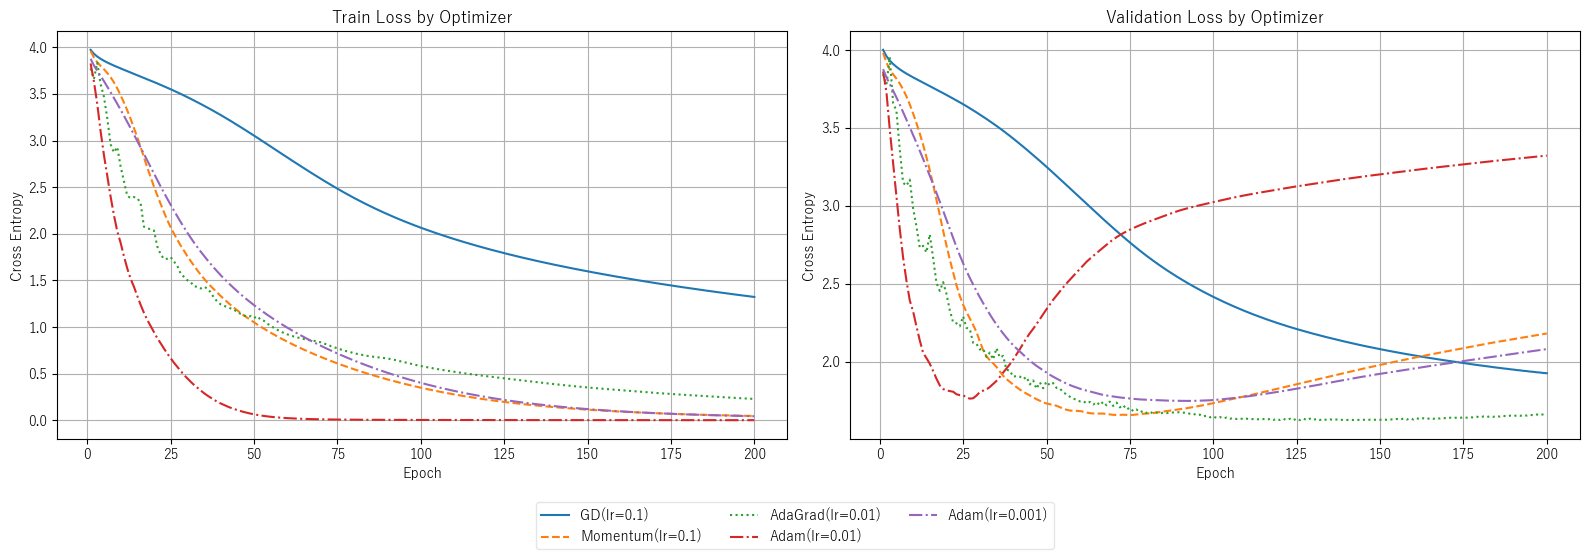

In [120]:
optimizer_test_plot(optimizer_results)

In [108]:
beta1 = [0.85, 0.9, 0.95]
beta2 = [0.99, 0.999, 0.9999]
adam_parameters = [{'beta1': beta1, 'beta2': beta2}]
adam_results = optimizer_test(M0, X_train, y_train, X_val, y_val, 
                                   optimizers=[Adam], parameters=adam_parameters)

Adam(beta1=0.95, beta2=0.9999): 100%|███████████████████████| 9/9 [02:32<00:00, 16.98s/model, val_loss=1.9952]


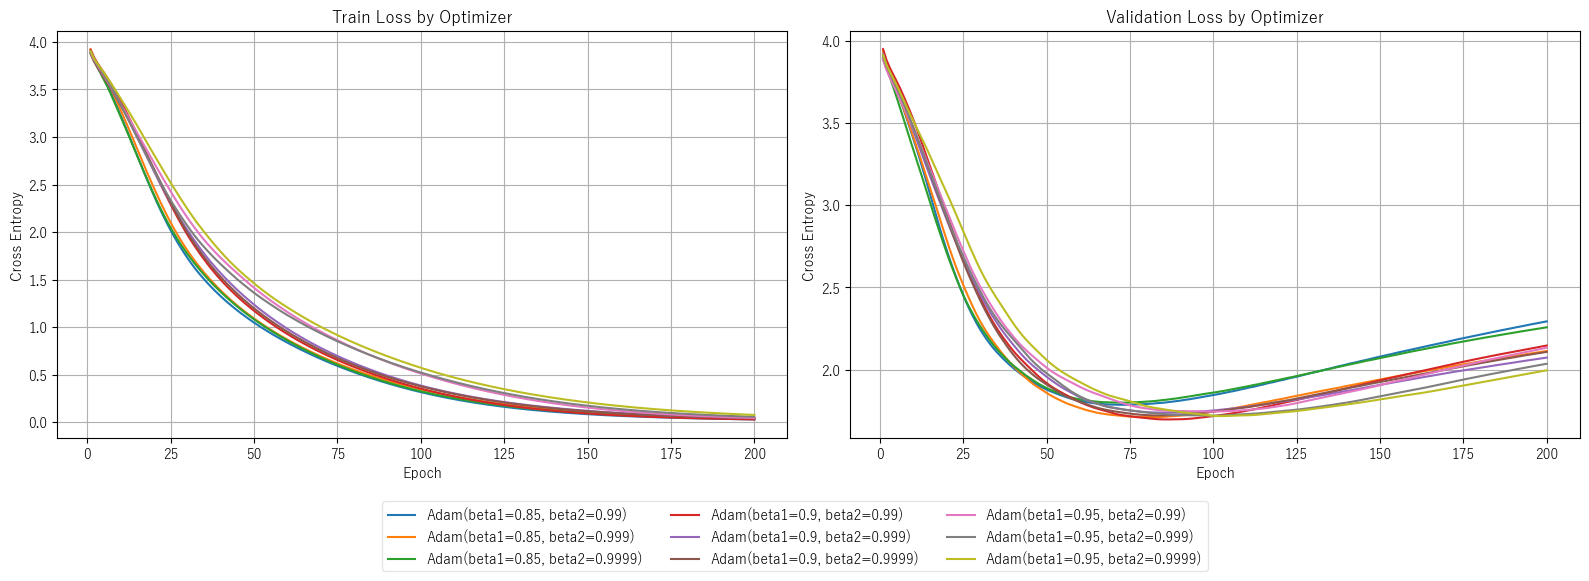

In [121]:
optimizer_test_plot(adam_results)

### **Learning Rate Scheduling**

Mantener la tasa de aprendizaje $\eta$ fija durante todo el entrenamiento es subóptimo: un $\eta$ grande permite descensos rápidos al principio pero impide converger con precisión, mientras que un $\eta$ pequeño converge con lentitud. El **learning rate scheduling** consiste en reducir $\eta$ a medida que avanza el entrenamiento. Consideramos dos estrategias:

**Decaimiento Lineal (con saturación)** (*linear decay with saturation*)

La tasa disminuye linealmente desde $\eta_0$ hasta un mínimo $\eta_{\min}$ en la época $T$, y se mantiene constante a partir de allí:

$$
\eta_t = \eta_0 \cdot \max\!\left(1 - \frac{t}{T},\; \frac{\eta_{\min}}{\eta_0}\right)
$$

El piso $\eta_{\min} > 0$ es la "saturación": evita que la tasa caiga a cero y que el entrenamiento se detenga por completo antes de converger.

**Decaimiento Exponencial** (*exponential decay*)

La tasa se multiplica por un factor $\gamma \in (0, 1)$ en cada época:

$$
\eta_t = \eta_0 \cdot \gamma^t
$$

El decaimiento es rápido al principio y se ralentiza asintóticamente. A diferencia del lineal, nunca alcanza cero exactamente.

Ambos esquemas buscan el mismo efecto: **dar pasos grandes al inicio para explorar el espacio de parámetros y pasos pequeños al final para refinar la solución**. En la práctica, con Adam el scheduling es menos crítico porque el optimizador ya adapta el paso efectivo por parámetro; sin embargo, combinarlo con un decaimiento de $\eta$ global puede mejorar la convergencia final.

In [93]:
linear_results, exponential_results = lr_scheduling_test(M0, X_train, y_train, X_val, y_val, 
                                             lr_mins=[1e-2, 1e-3, 1e-4, 1e-5],gammas=[0.995, 0.99, 0.98, 0.97])

exponential(gamma=0.97): 100%|████████████████████| 8/8 [03:35<00:00, 26.98s/model, val_loss=3.4693]


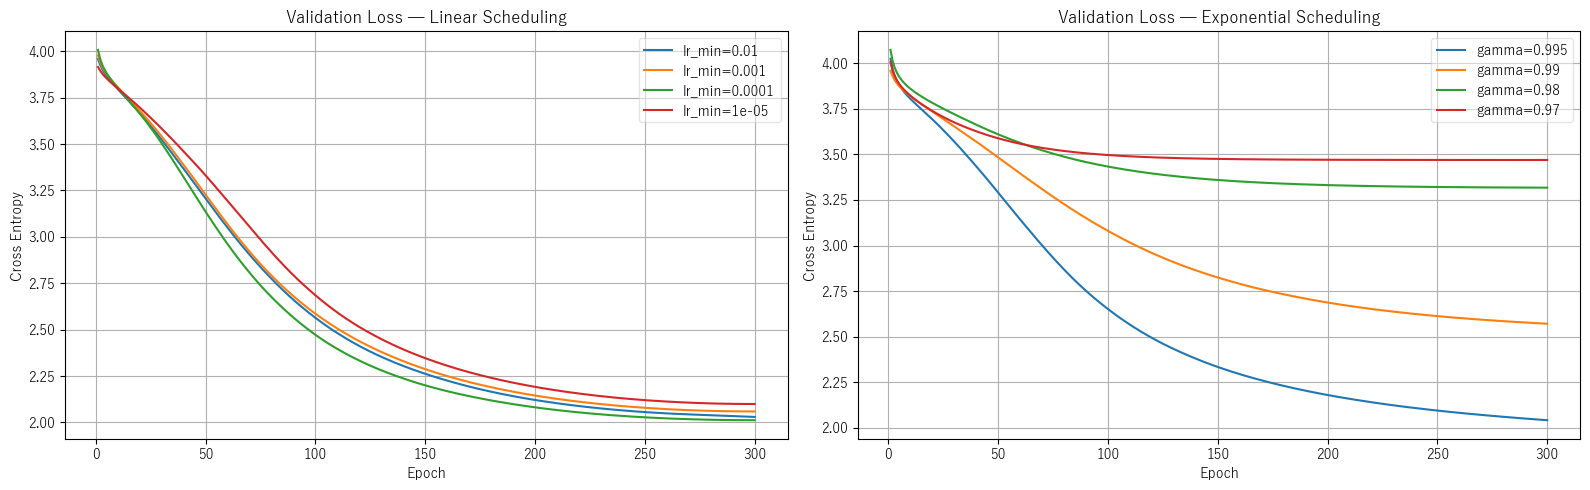

In [94]:
lr_scheduling_test_plot(linear_results, exponential_results)

### **Regularización:** *Early Stopping + Weight Decay*

Con el fin de evitar el sobre-ajuste de la red, se implementaron las siguiente técnicas de regularización de redes neuronales:

**Early Stopping**: El algoritmo de entrenamiento en lugar de realizar un número fijo de epocas, puede decidir el frenar antes de llegar a al número máximo de épocas con el criterio de cierta cantidad de épocas sin mejora de la función de pérdida sobre el set de validación. A esta cantidad se le llama **paciencia**.

**Weight Decay (AdamW)**: La regularización $L_2$ clásica agrega un término de penalización a la función de costo:

$$
\mathcal{L}_{\text{p}}(\boldsymbol{\theta}) = \mathcal{L}(\boldsymbol{\theta}) + \frac{\lambda}{2} \|\boldsymbol{\theta}\|^2
$$

En el gradiente descendente estándar esto produce el efecto de *shrinkage* $(1-\eta\lambda)$ sobre los pesos, de ahí el nombre *weight decay*. Sin embargo, **combinado con Adam esto no funciona correctamente**: el optimizador escala cada componente del gradiente por $1/\sqrt{\hat{\mathbf{v}}_t}$, de modo que el término de regularización $\lambda\,\boldsymbol{\theta}$ también queda escalado de forma no uniforme por dimensión, distorsionando el efecto de la penalización.

La solución es el **weight decay desacoplado** (*decoupled weight decay*, AdamW): en lugar de incluir la penalización en el gradiente, se aplica directamente sobre los parámetros **después** del paso de Adam, de forma independiente al optimizador:

$$
\boldsymbol{\theta}_{t+1} = (1 - \eta\lambda)\,\boldsymbol{\theta}_t - \eta\,\frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon}
$$

Así el decaimiento $(1-\eta\lambda)$ es uniforme para todos los parámetros, independientemente de la magnitud de sus gradientes históricos. Esto restaura la interpretación original del weight decay como una penalización sobre la norma de los pesos, sin interferir con la adaptatividad de Adam.

In [116]:
optimizer_info = {GD : {'lr':0.1}, AdamW : {'lr':0.01}}
weight_decay_results = weight_decay_test(M0, X_train, y_train, X_val, y_val, 
                  optimizer_info=optimizer_info, weight_decays=[0.0, 1e-4, 1e-3, 1e-2, 1e-1])

AdamW(wd=0.1): 100%|██████████████████████████████████████| 10/10 [02:51<00:00, 17.14s/model, val_loss=2.8192]


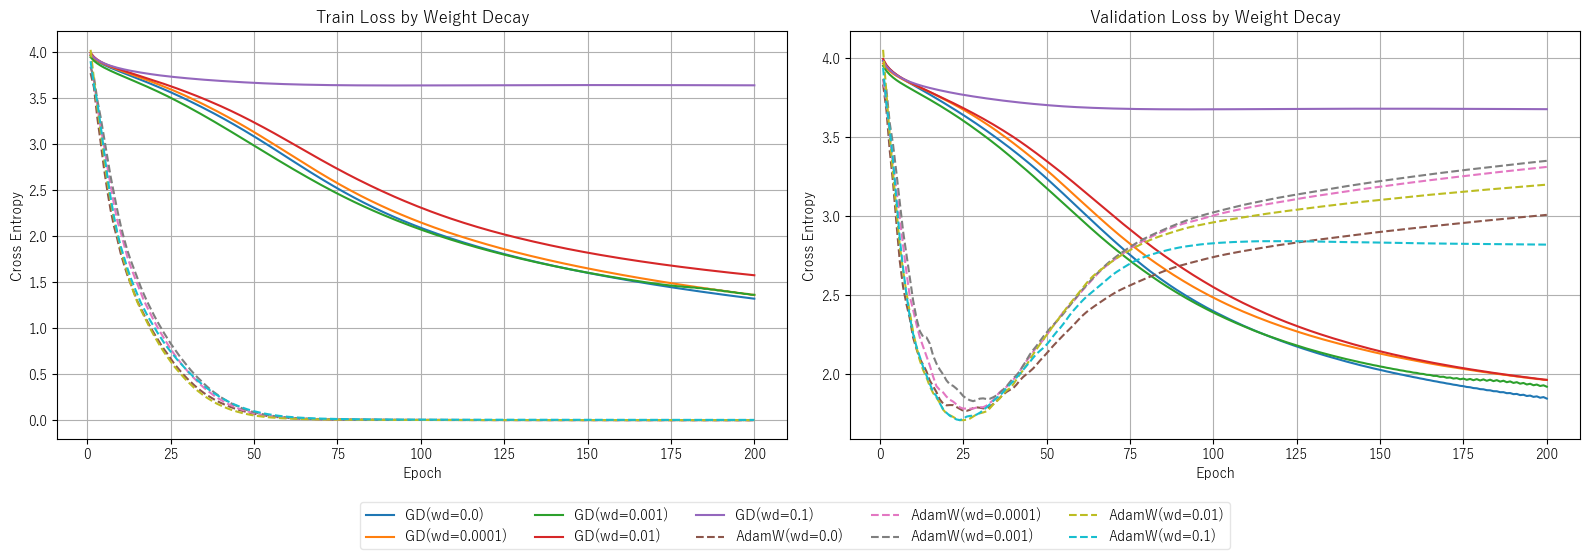

In [119]:
weight_decay_test_plot(weight_decay_results)

## **Modelo** $\boldsymbol{M_1}$

$$
\color{red} COMPLETAR
$$

In [ ]:
M1_param_grid = {
    'layers': [
        [(128, 'relu')],
        [(256, 'relu')],
        [(512, 'relu')],
        [(1024, 'relu')],
        [(128, 'relu'), (64, 'relu')],
        [(256, 'relu'), (64, 'relu')],
        [(512, 'relu'), (128, 'relu')],
        [(1024, 'relu'), (128, 'relu')]
    ],
    'gamma' : [0.995, 0.99, 0.97],
    'batch_size' : [64, 256, 512],
}
M1_optim_param_grid =  {'lr' : [1e-2, 1e-1], 'weight_decay': [1e-1, 1e-2, 1e-3]}

M1_fit_params = {'epochs' : 100,  'patience' : 10, 'lr_schedule' : 'exponential'}

M1_gs = grid_search(
    X_train, y_train, X_val, y_val,
    param_grid=M1_param_grid,
    optimizer_param_grid=M1_optim_param_grid,
    fit_params=M1_fit_params,
    model_class=NN,
    optimizer_class=AdamW
)

GRID SEARCH [NN / Adam] — 288 models [layers(8) x gamma(2) x batch_size(3) x lr(2) x weight_decay(3)]


[512→64]: 100%|██████████| 288/288 [23:56<00:00,  4.99s/model, best=1.2715, val_loss=3.4818]


In [63]:
M1_gs.drop(columns=['layers_config']).head(15)

,layers,gamma,batch_size,lr,weight_decay,val_loss,val_f1_macro,epochs_trained
1,[512],0.97,64,0.01,0.100,1.2715,0.7063,39
2,[512],0.99,256,0.01,0.100,1.4479,0.6788,15
3,[512],0.97,512,0.01,0.100,1.4502,0.6761,17
4,[512],0.97,256,0.01,0.100,1.4890,0.6852,15
5,[256],0.97,64,0.01,0.100,1.5040,0.6853,28
6,[256],0.97,256,0.01,0.100,1.5353,0.6726,16
7,[512],0.97,512,0.01,0.001,1.5589,0.6912,18
8,[512],0.97,512,0.01,0.010,1.5625,0.6755,16
9,[512],0.99,512,0.01,0.100,1.5702,0.6755,17
10,[512],0.99,256,0.01,0.001,1.5769,0.6891,14


In [42]:
M1_config = M1_gs.iloc[0] 
M1_layers = M1_config['layers_config']
M1_fit_params.update({'batch_size' : M1_config['batch_size'], 'gamma' : M1_config['gamma']})
M1_optimizer_params = {'lr' : M1_config['lr'], 'weight_decay' : M1_config['weight_decay']}
print('M1 Layers', M1_layers)
print('M1 Params') 
pprint({**M1_fit_params, **M1_optimizer_params}, indent=2)

M1 Layers [(512, 'relu')]
M1 Params
{ 'batch_size': np.int64(64),
  'epochs': 100,
  'gamma': np.float64(0.97),
  'lr': np.float64(0.01),
  'lr_schedule': 'exponential',
  'patience': 10,
  'weight_decay': np.float64(0.1)}


In [43]:
# # hardcodear resultado grid-search
# M1_layers = [(512, 'relu')]
# M1_fit_params = {'batch_size': np.int64(64), 'epochs': 100, 'gamma': np.float64(0.97), 'lr_schedule': 'exponential', 'patience': 10}
# M1_optimizer_params = {'lr': np.float64(0.01), 'weight_decay': np.float64(0.1)}

In [ ]:
M1 = NN(
    input_size, output_size, 
    layers=M1_layers, optimizer=AdamW, 
    optim_params=M1_optimizer_params
	)
M1_train_hist = M1.fit(X_train, y_train, X_val, y_val, **M1_fit_params) 

Training:  34%|███▍      | 34/100 [00:30<00:59,  1.12epoch/s, train_loss=0.0044, val_loss=1.2995]


Training [early stopping] — epoch: 35 | train_loss: 0.0044 | val_loss: 1.2995 | time: 30.4s


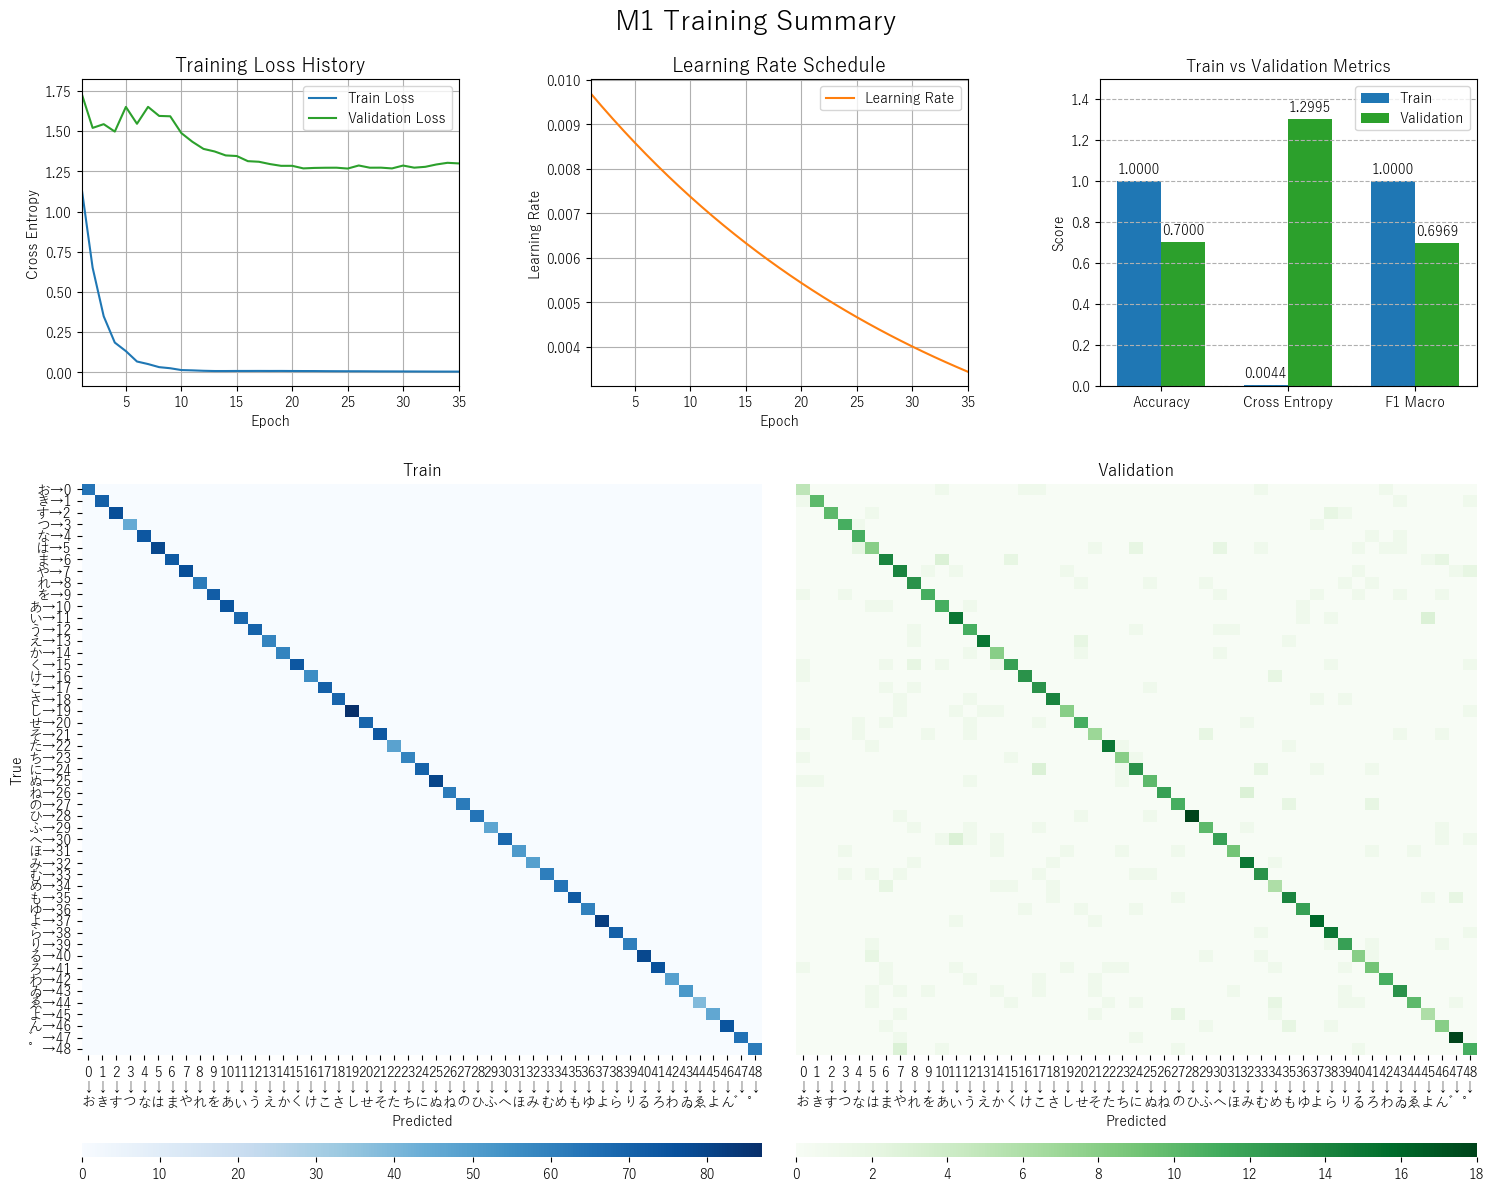

In [45]:
training_summary(M1, M1_train_hist, X_train, y_train, X_val, y_val, title='M1 Training Summary')

## 4. Desarrollo de una Red Neuronal con PyTorch

## **Modelo** $\boldsymbol{M_2}$

$$
\color{red} COMPLETAR
$$

In [54]:
M2 = TorchNN(
    input_size, output_size, 
    layers=M1_layers, optimizer=torch.optim.AdamW,
    optim_params=M1_optimizer_params
    )
M2_train_hist = M2.fit(X_train, y_train, X_val, y_val, **M1_fit_params)

Training:  30%|███       | 30/100 [00:02<00:05, 13.42epoch/s, train_loss=0.0055, val_loss=1.3424]


Final [early stopping] — epoch: 31 | train_loss: 0.0055 | val_loss: 1.3424 | time: 2.2s


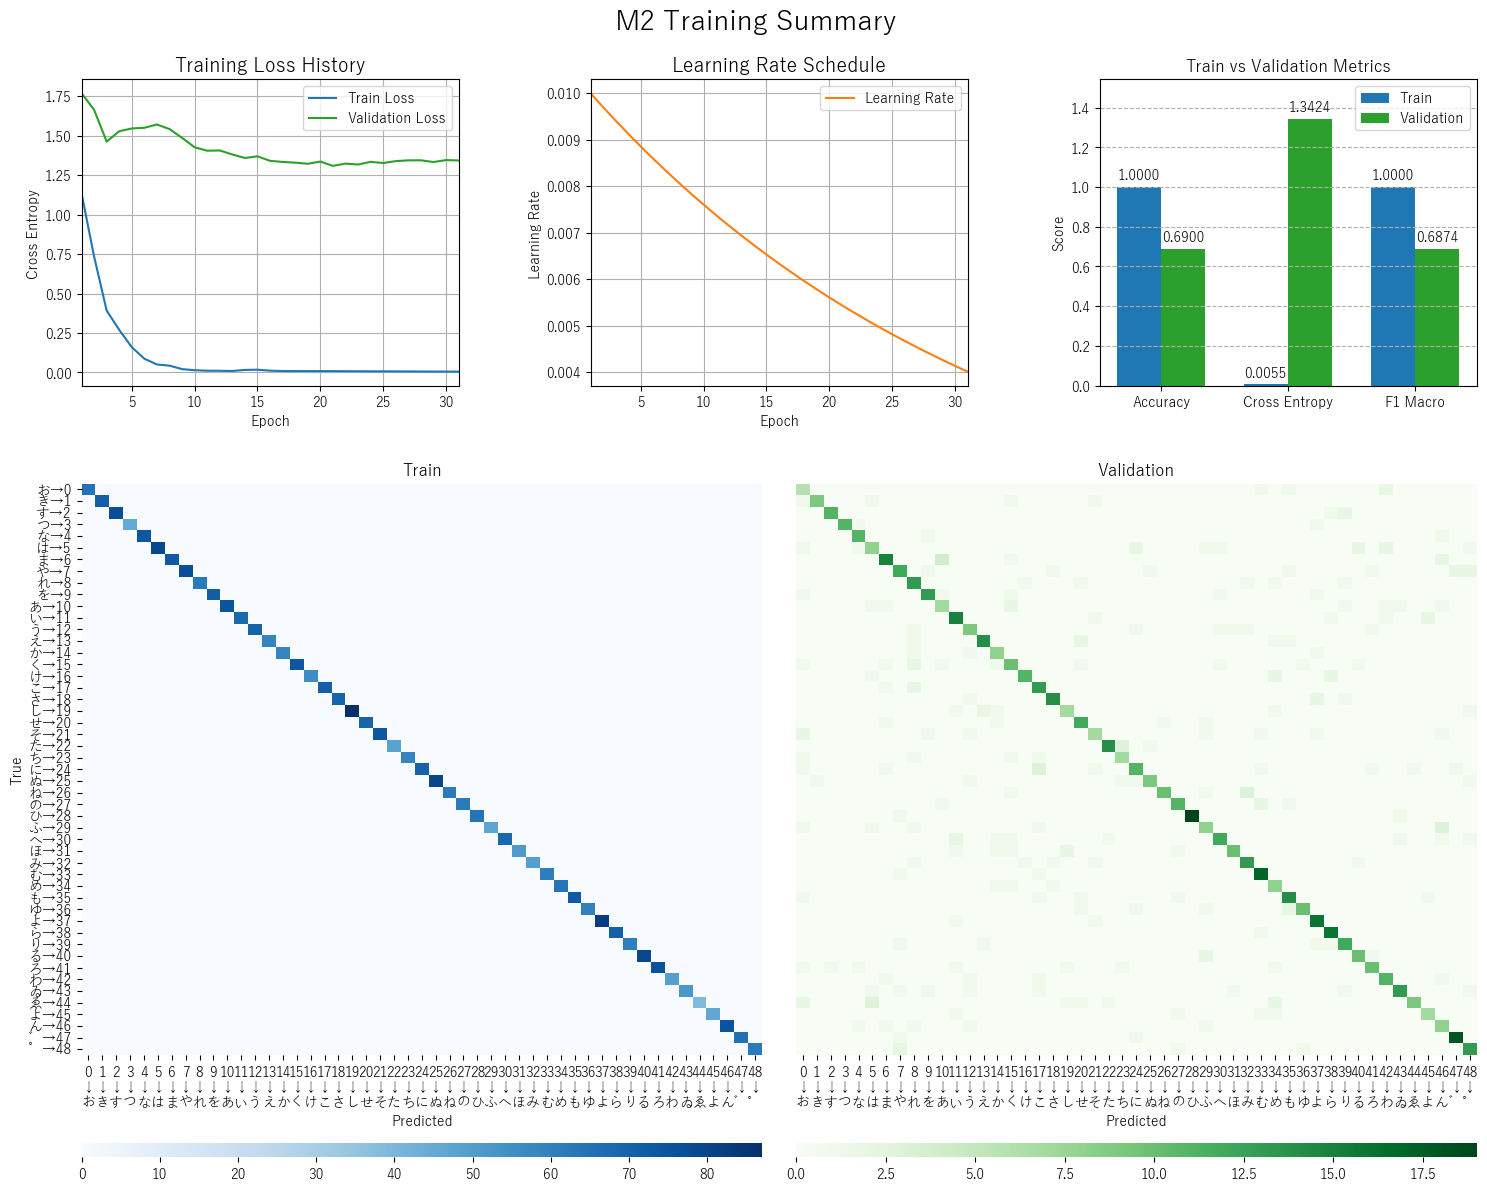

In [55]:
training_summary(M2, M2_train_hist, X_train, y_train, X_val, y_val, title='M2 Training Summary')

## **Modelo** $\boldsymbol{M_3}$

$$
\color{red} COMPLETAR
$$

In [56]:
M3_param_grid = {
    'layers' : [
        [(256, 'silu')],
        [(256, 'gelu')],
        [(256, 'leaky_relu')],
        [(512, 'silu')],
        [(512, 'gelu')],
        [(512, 'leaky_relu')],
        [(256, 'silu'), (64, 'gelu')],
        [(256, 'gelu'), (64, 'silu')],
        [(256, 'silu'), (64, 'leaky_relu')],
        [(512, 'silu'), (64, 'gelu')],
        [(512, 'silu'), (64, 'leaky_relu')],
	],
    'dropout' : [0.1, 0.3, 0.5],
    'gamma' : [0.99, 0.97],
    'batch_size' : [258, 512]
}

M3_fit_params = M1_fit_params
M3_optim_param_grid = {'lr': [1e-2], 'weight_decay': [1e-1, 1e-2, 1e-3],}

M3_gs = grid_search(
    X_train, y_train, X_val, y_val, param_grid=M3_param_grid, fit_params=M3_fit_params, 
	model_class=TorchNN, optimizer_class=torch.optim.AdamW, optimizer_param_grid=M3_optim_param_grid
    )

GRID SEARCH [TorchNN / AdamW] — 396 models [layers(11) x dropout(3) x gamma(2) x batch_size(2) x lr(1) x weight_decay(3)]


[512→64]: 100%|██████████| 396/396 [03:12<00:00,  2.06model/s, best=1.3024, val_loss=1.5813]


In [57]:
M3_gs.drop(columns=['layers']).head(15)

,layers_config,dropout,gamma,batch_size,lr,weight_decay,val_loss,val_f1_macro,epochs_trained
1,"[(512, silu)]",0.5,0.99,512,0.01,0.100,1.3024,0.7079,18
2,"[(256, silu)]",0.5,0.97,512,0.01,0.100,1.3264,0.6745,23
3,"[(512, silu)]",0.5,0.97,258,0.01,0.100,1.3335,0.6912,17
4,"[(512, leaky_relu)]",0.5,0.99,258,0.01,0.100,1.3358,0.6926,17
5,"[(512, gelu)]",0.5,0.99,512,0.01,0.100,1.3362,0.6754,17
6,"[(512, leaky_relu)]",0.5,0.97,512,0.01,0.100,1.3408,0.7052,26
7,"[(256, silu)]",0.5,0.97,258,0.01,0.100,1.3475,0.6677,16
8,"[(256, silu)]",0.5,0.99,512,0.01,0.100,1.3502,0.6758,21
9,"[(256, silu)]",0.5,0.99,512,0.01,0.001,1.3560,0.6843,17
10,"[(512, gelu)]",0.5,0.97,512,0.01,0.100,1.3562,0.6693,22


In [58]:
M3_config = M3_gs.iloc[0] 
M3_layers = M3_config['layers_config']
M3_fit_params.update({'batch_size' : M3_config['batch_size'], 'gamma' : M3_config['gamma']})
M3_optimizer_params = {'lr' : M3_config['lr'], 'weight_decay' : M3_config['weight_decay']}
print('M3 Layers', M3_layers)
print('M3 Fit Params')
pprint({**M3_fit_params, **M3_optimizer_params}, indent=2)

M3 Layers [(512, 'silu')]
M3 Fit Params
{ 'batch_size': np.int64(512),
  'epochs': 100,
  'gamma': np.float64(0.99),
  'lr': np.float64(0.01),
  'lr_schedule': 'exponential',
  'patience': 10,
  'weight_decay': np.float64(0.1)}


In [60]:
M3 = TorchNN(input_size, output_size, layers=M3_layers, dropout=M3_config['dropout'],
             optimizer=torch.optim.AdamW, optim_params=M3_optimizer_params)
M3_train_hist = M3.fit(X_train, y_train, X_val, y_val, **M3_fit_params) 

Training:  16%|█▌        | 16/100 [00:00<00:02, 33.19epoch/s, train_loss=0.0438, val_loss=1.3217]


Final [early stopping] — epoch: 17 | train_loss: 0.0438 | val_loss: 1.3217 | time: 0.5s


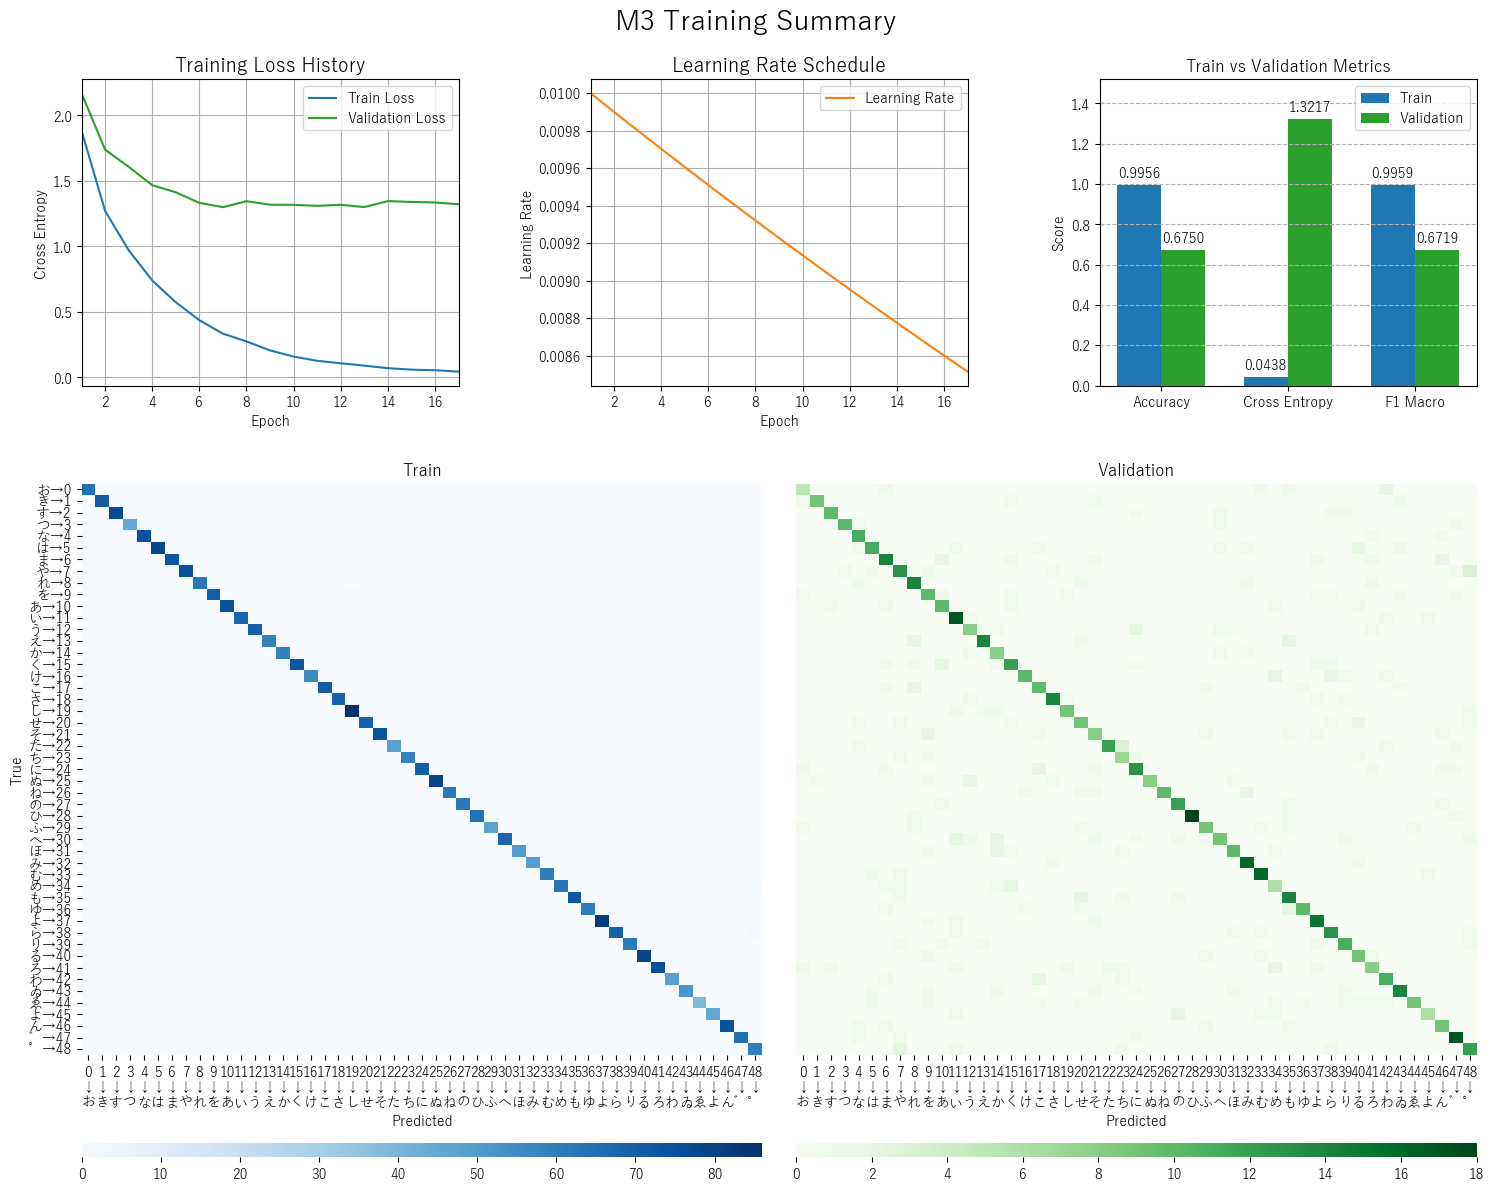

In [61]:
training_summary(M3, M3_train_hist, X_train, y_train, X_val, y_val, title='M3 Training Summary')